# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [83]:
import os

data_dir = "../data"  # Ruta de carpeta con archivos de texto
gutenberg_texts = []  # Lista para guardar contenido de cada libro
gutenberg_filenames = []  # Lista para guardar nombres de archivos

# Recorre todos los archivos en la carpeta data
for filename in os.listdir(data_dir):
    # Filtra solo archivos .txt y limita a máximo 1000 libros
    if filename.endswith('.txt') and len(gutenberg_texts) < 1000:
        try:
            # Abre archivo con codificación UTF-8
            with open(os.path.join(data_dir, filename), 'r', encoding='utf-8') as f:
                text = f.read()
                # Solo incluye archivos con más de 1000 caracteres (evita archivos muy pequeños)
                if len(text) > 1000:
                    gutenberg_texts.append(text)  # Agrega contenido a lista de textos
                    gutenberg_filenames.append(filename)  # Agrega nombre a lista de nombres
        except:  # Si hay error al leer, lo ignora y continúa con siguiente archivo
            pass

print(f"Corpus Gutenberg cargado: {len(gutenberg_texts)} libros")  # Muestra cantidad de libros cargados

Corpus Gutenberg cargado: 1000 libros


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# 1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
# TfidfVectorizer convierte documentos de texto a matriz TF-IDF
# max_features=1000: mantiene los 1000 términos más frecuentes
# min_df=1: incluye términos que aparecen al menos 1 vez
# max_df=0.95: excluye términos que aparecen en más del 95% de documentos
vectorizer = TfidfVectorizer(max_features=1000, min_df=1, max_df=0.95, stop_words=None)
tfidf_matrix = vectorizer.fit_transform(gutenberg_texts)  # Transforma todos los documentos
print(f"Matriz TF-IDF creada: {tfidf_matrix.shape}")  # Muestra dimensión (documentos x términos)

Matriz TF-IDF creada: (1000, 1000)


In [85]:
# 2. Calcula TF-IDF utilizando sklearn
# (tfidf_matrix > 0).sum(axis=0) cuenta en cuántos documentos aparece cada término
# flatten() convierte la matriz en un array unidimensional
# df = Document Frequency (número de documentos con cada término)
df = np.array((tfidf_matrix > 0).sum(axis=0)).flatten()
print(f"DF mínimo: {df.min()} \nDF máximo: {df.max()}")  # Muestra rango de frecuencias

DF mínimo: 1 
DF máximo: 950


In [86]:
# 3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos
# get_feature_names_out() obtiene la lista de todos los términos en el vocabulario
terms = vectorizer.get_feature_names_out()
# Crea DataFrame con 3 columnas: términos, cuántos docs tienen cada término (DF), y su IDF
df_result = pd.DataFrame({
    'Término': terms,
    'DF': df,  # Document Frequency (en cuántos docs aparece)
    'IDF': vectorizer.idf_  # IDF (peso para penalizar términos comunes)
})

# Ordena por DF descendente (términos más frecuentes primero)
df_result = df_result.sort_values('DF', ascending=False)
print(f"\nTop 20 términos por Document Frequency:")
print(df_result.head(20))  # Muestra los 20 términos más frecuentes


Top 20 términos por Document Frequency:
     Término   DF       IDF
533     made  950  1.051241
983    would  949  1.052293
277    every  948  1.053346
36     after  947  1.054400
952     well  946  1.055456
627     over  946  1.055456
628      own  945  1.056512
206      day  944  1.057570
860     take  942  1.059688
373     good  942  1.059688
390      had  941  1.060750
381    great  941  1.060750
507     like  940  1.061812
545       me  940  1.061812
483     last  940  1.061812
535      man  940  1.061812
597    never  939  1.062875
394     hand  938  1.063939
831    still  938  1.063939
58   another  938  1.063939


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [87]:
# 1. Dada una consulta, construye el vector de consulta
# Transform() convierte la consulta de texto a un vector TF-IDF usando el mismo vocabulario
from sklearn.metrics.pairwise import cosine_similarity

query = "war"  # Consulta de ejemplo
query_vector = vectorizer.transform([query])  # Convierte a vector TF-IDF

In [88]:
# 2. Calcula la similitud coseno entre la consulta y cada documento
# cosine_similarity mide qué tan similar es la consulta a cada documento (0 a 1)
# flatten() convierte resultado en array 1D para más fácil manipulación
scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

In [89]:
# 3. Genera un ranking de los documentos ordenados por relevancia
# argsort() retorna índices que ordenarían el array de menor a mayor
# [::-1] invierte el orden para que mayor similitud aparezca primero
ranking_indices = scores.argsort()[::-1]

In [90]:
# 4. Muestra los resultados en una tabla
# Crea DataFrame con top 10 documentos más similares a la consulta
results_tfidf = pd.DataFrame({
    'Documento': [gutenberg_filenames[i] for i in ranking_indices[:10]],  # Nombres de los 10 mejores docs
    'Score': scores[ranking_indices[:10]]  # Sus scores de similitud
})
print(results_tfidf)  # Muestra tabla con resultados TF-IDF

                                           Documento     Score
0     Abraham Lincoln's Second Inaugural Address.txt  0.623474
1  Worldwide Effects of Nuclear War_ Some Perspec...  0.373701
2                                Abraham Lincoln.txt  0.214025
3  Pharsalia; Dramatic Episodes of the Civil Wars...  0.198524
4               The United States Bill of Rights.txt  0.193531
5  A Footnote to History_ Eight Years of Trouble ...  0.184139
6                                   Trinity Site.txt  0.180028
7  Beowulf_ An Anglo-Saxon Epic Poem - Beowulf_ A...  0.179230
8                        The Great War Syndicate.txt  0.177914
9                   Lincoln's Gettysburg Address.txt  0.177497


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [91]:
# 1. Implementa un sistema de recuperación usando BM25
# BM25Okapi es una algoritmo de recuperación probabilístico más sofisticado que TF-IDF
from rank_bm25 import BM25Okapi

# Tokeniza todos los documentos (divide en palabras y convierte a minúsculas)
tokenized_corpus = [doc.lower().split() for doc in gutenberg_texts]
# Inicializa BM25 con el corpus tokenizado
bm25 = BM25Okapi(tokenized_corpus) # Realiza los pasos del 2-5 gracias a la implementación de BM25Okapi

In [92]:
# 2. Usa la misma consulta del ejercicio anterior
# Tokeniza la consulta igual que los documentos (minúsculas y palabras)
query_tokens = query.lower().split()

In [93]:
# 3. Calcula el score BM25 para cada documento y genera un ranking
# get_scores() devuelve scores BM25 para todos los documentos con respecto a la consulta
bm25_scores = bm25.get_scores(query_tokens)
# Ordena índices por score descendente (mayor relevancia primero)
ranking_indices_bm25 = bm25_scores.argsort()[::-1]

In [94]:
# 4. Compara manualmente con el ranking de TF-IDF
# Crea DataFrame con top 10 documentos según BM25
comparison = pd.DataFrame({
    'Documento': [gutenberg_filenames[i] for i in ranking_indices_bm25[:10]],  # Nombres de 10 mejores docs
    'Score': bm25_scores[ranking_indices_bm25[:10]]  # Sus scores BM25
})
print(comparison)  # Muestra tabla con resultados BM25

                                           Documento     Score
0  Pharsalia; Dramatic Episodes of the Civil Wars...  3.840475
1           The History of the Thirty Years' War.txt  3.834871
2                        The Great War Syndicate.txt  3.833036
3  Indian Why Stories_ Sparks from War Eagle's Lo...  3.832059
4             Indian Heroes and Great Chieftains.txt  3.827891
5  The Outline of History_ Being a Plain History ...  3.821647
6                             The War in the Air.txt  3.820426
7  The Underdogs_ A Novel of the Mexican Revoluti...  3.819921
8                       A History of Aeronautics.txt  3.818390
9                                 The Art of War.txt  3.816879


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

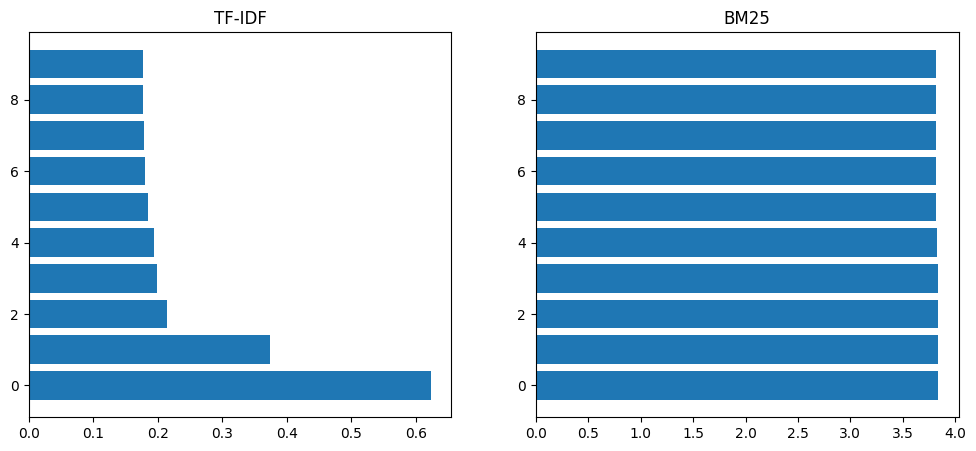

In [ ]:
# 1. Utiliza un gráfico de barras para visualizar los scores
import matplotlib.pyplot as plt

# Crea figura con 2 subplots lado a lado (TF-IDF y BM25)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Agregar título general a la figura
fig.suptitle('Comparativa entre TF-IDF vs BM25', fontsize=16, fontweight='bold')

# Gráfico izquierdo: barras horizontales con scores TF-IDF
ax1.barh(range(10), results_tfidf['Score'])
ax1.set_title('TF-IDF')

# Gráfico derecho: barras horizontales con scores BM25 (naranja)
ax2.barh(range(10), comparison['Score'], color='orange')
ax2.set_title('BM25')

plt.tight_layout()
plt.show()  # Muestra ambos gráficos

In [96]:
# 2. Compara los rankings visualmente
# Crea tabla lado a lado con scores TF-IDF y BM25 para fácil comparación
print("TF-IDF vs BM25:")
print(pd.DataFrame({
    'TF-IDF': results_tfidf['Score'].values,
    'BM25': comparison['Score'].values
}))

TF-IDF vs BM25:
     TF-IDF      BM25
0  0.623474  3.840475
1  0.373701  3.834871
2  0.214025  3.833036
3  0.198524  3.832059
4  0.193531  3.827891
5  0.184139  3.821647
6  0.180028  3.820426
7  0.179230  3.819921
8  0.177914  3.818390
9  0.177497  3.816879


In [97]:
# 3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
# Calcula diferencia absoluta entre scores TF-IDF y BM25
diff = np.abs(results_tfidf['Score'].values - comparison['Score'].values)
# Encuentra el índice con la mayor diferencia
idx = np.argmax(diff)
# Muestra el documento con mayor diferencia entre métodos
print(f"Mayor diferencia: {results_tfidf['Documento'].iloc[idx]}")
print(f"Diferencia: {diff[idx]:.4f}")

Mayor diferencia: Beowulf_ An Anglo-Saxon Epic Poem - Beowulf_ An Anglo-Saxon Epic Poem.txt
Diferencia: 3.6407


In [98]:
# 4. ¿A qué se podría deber esta diferencia?
# Explica las diferencias fundamentales entre TF-IDF y BM25
print("""
DIFERENCIAS ENTRE TF-IDF Y BM25:

TF-IDF: 
- Normaliza scores por la longitud del documento
- Usa escala logarítmica de frecuencias
- Puede favorecer documentos cortos

BM25:
- Saturación de frecuencia de términos (no crece infinitamente)
- Penaliza documentos muy largos pero de forma controlada
- Busca longitud óptima de documentos
- Mejor desempeño en recuperación de información

RESULTADO:
- Diferentes documentos pueden ranquearse distinto
- BM25 es más robusto en la mayoría de casos
""")


DIFERENCIAS ENTRE TF-IDF Y BM25:

TF-IDF: 
- Normaliza scores por la longitud del documento
- Usa escala logarítmica de frecuencias
- Puede favorecer documentos cortos

BM25:
- Saturación de frecuencia de términos (no crece infinitamente)
- Penaliza documentos muy largos pero de forma controlada
- Busca longitud óptima de documentos
- Mejor desempeño en recuperación de información

RESULTADO:
- Diferentes documentos pueden ranquearse distinto
- BM25 es más robusto en la mayoría de casos

